In [1]:
from pathlib import Path
import torch

from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.utils import create_graph_files

model_name = "qwen3-4b"
transcoder_name = "mwhanna/qwen3-4b-transcoders"
backend = 'transformerlens'  # change to 'nnsight' for the nnsight backend!
model = ReplacementModel.from_pretrained(
    model_name, transcoder_name, dtype=torch.bfloat16, lazy_encoder=True, backend=backend
)

Fetching 36 files:   0%|          | 0/36 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 48.00 MiB. GPU 0 has a total capacity of 23.64 GiB of which 1024.00 KiB is free. Process 3801174 has 15.71 GiB memory in use. Including non-PyTorch memory, this process has 7.92 GiB memory in use. Of the allocated memory 7.46 GiB is allocated by PyTorch, and 31.71 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [3]:
from attribute_utils import format_qwen

messages = [
    {"role": "system", "content": "Answer the question in one word and no more."},
    {"role": "user", "content": "abuja is to nigeria as amman is to?"},
]

prompt = format_qwen(messages, add_generation_prompt=True, enable_thinking=False)

max_n_logits = 10
desired_logit_prob = 0.95
max_feature_nodes = 8192
batch_size = 256
offload = "cpu"
verbose = True

In [4]:
graph = attribute(
    prompt=prompt,
    model=model,
    max_n_logits=max_n_logits,
    desired_logit_prob=desired_logit_prob,
    batch_size=batch_size,
    max_feature_nodes=max_feature_nodes,
    offload=offload,
    verbose=verbose,
)

Phase 0: Precomputing activations and vectors
Precomputation completed in 11.90s
Found 64704 active features
Phase 1: Running forward pass
Forward pass completed in 0.65s
Phase 2: Building input vectors
Using 1 salient logits with cumulative probability 0.9570
Will include 8192 of 64704 feature nodes
Input vectors built in 1.92s
Phase 3: Computing logit attributions
<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Logit attributions completed in 0.84s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:13<00:00, 586.78it/s]
Feature attributions completed in 13.96s
Attribution completed in 34.11s


In [5]:
graph_dir = "graphs/qwen3-4b"
graph_name = "analogies_0.pt"
graph_dir = Path(graph_dir)
# create intermediate parent directories if needed
graph_dir.mkdir(parents=True, exist_ok=True)
graph_path = graph_dir / graph_name

graph.to_pt(graph_path)

In [6]:
import torch
import matplotlib.pyplot as plt
from circuit_tracer.graph import Graph, normalize_matrix, compute_influence


def plot_influence_per_layer(graph: Graph):
    print(graph.adjacency_matrix.shape)
    n_logits = len(graph.logit_targets)
    n_tokens = len(graph.input_tokens)
    n_features = len(graph.selected_features)
    n_layers = graph.cfg.n_layers

    error_start = n_features
    error_end = error_start + n_layers * n_tokens

    logit_weights = torch.zeros(
        graph.adjacency_matrix.shape[0], device=graph.adjacency_matrix.device
    )
    logit_weights[-n_logits:] = graph.logit_probabilities

    node_influence = compute_influence(normalize_matrix(graph.adjacency_matrix), logit_weights)

    # Error influence per layer: errors are laid out as error[layer][pos]
    error_infl = node_influence[error_start:error_end].reshape(n_layers, n_tokens)
    error_per_layer = error_infl.sum(dim=-1).cpu()

    # Feature influence per layer: look up each selected feature's layer
    feature_layers = graph.active_features[graph.selected_features][:, 0]  # (n_features,)
    feature_infl = node_influence[:n_features].cpu()
    feature_per_layer = torch.zeros(n_layers)
    feature_per_layer.scatter_add_(0, feature_layers.cpu().long(), feature_infl)

    total_per_layer = feature_per_layer + error_per_layer

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    x = range(n_layers)

    axes[0].bar(x, error_per_layer.numpy())
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Influence")
    axes[0].set_title("Error-node influence per layer")

    axes[1].bar(x, feature_per_layer.numpy(), label="features")
    axes[1].bar(x, error_per_layer.numpy(), bottom=feature_per_layer.numpy(), label="errors")
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Influence")
    axes[1].set_title("Total influence per layer (features + errors)")
    axes[1].legend()

    plt.tight_layout()
    return fig, {"error": error_per_layer, "feature": feature_per_layer, "total": total_per_layer}


torch.Size([9193, 9193])


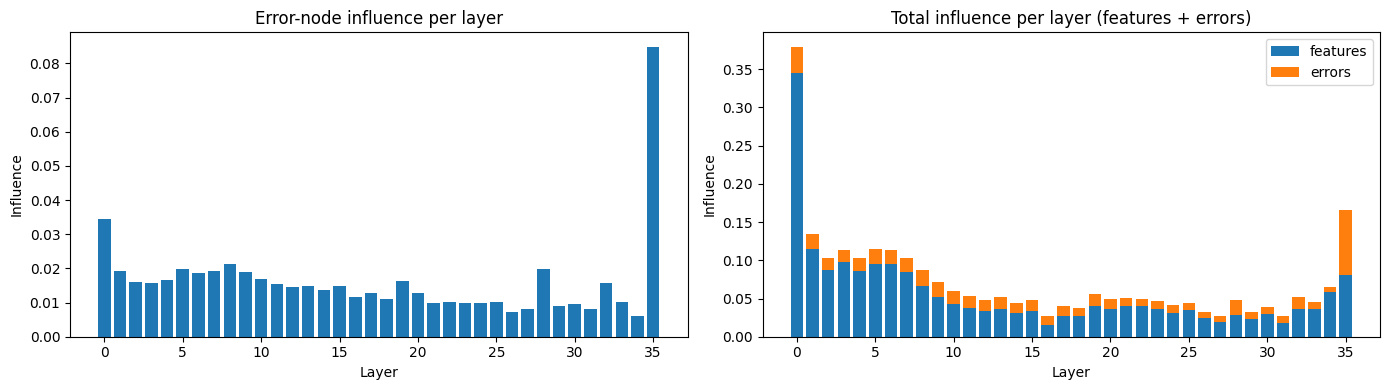

In [7]:
from circuit_tracer import Graph
g = Graph.from_pt("graphs/qwen3-4b/analogies_0.pt")
ax, per_layer = plot_influence_per_layer(g)
plt.show()

In [6]:
from circuit_tracer.utils.create_graph_files import create_graph_files_from_prune_graph, create_graph_files

slug = "analogies_0"  # this is the name that you assign to the graph
graph_file_dir = "./graph_files"  # where to write the graph files. no need to make this one; create_graph_files does that for you
node_threshold = 0.7  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
edge_threshold = 0.95  # keep only the minimum # of edges whose cumulative influence is >= 0.98

create_graph_files(
    graph_or_path=graph_path,  # the graph to create files for
    slug=slug,
    output_path=graph_file_dir,
    node_threshold=node_threshold,
    edge_threshold=edge_threshold,
)
# create_graph_files_from_prune_graph(pg, slug="example", output_path="graphs/example_graph.json")

In [7]:
from circuit_tracer.frontend.local_server import serve


port = 8046
server = serve(data_dir="graphs_files/", port=port)

from IPython.display import IFrame

print(f"Use the IFrame below, or open your graph here: f'http://localhost:{port}/index.html'")
display(IFrame(src=f"http://localhost:{port}/index.html", width="100%", height="800px"))

Use the IFrame below, or open your graph here: f'http://localhost:8046/index.html'


In [6]:
server.stop()

In [ ]:
import torch
from summarization.attr_graph import AttrGraph
from summarization.prune import prune_attr_graph
from summarization.token_attribution import get_token_attribution
from summarization.utils import _build_index_sets
from eval.prune_graphs import _token_weights_for_embeddings
from summarization.ilp_cluster import cluster_graph_ilp
from summarization.cluster import clusters_to_supernodes
from summarization.cluster_viz import supernode_graph_figure
from summarization.summarize import SummaryGraph

graph_path = "generated_graphs/Beijing.pt"

# Load as AttrGraph so we can run SHAP against its stored prompt.
ag = AttrGraph.from_graph(graph_path)

# HF-loadable id for SHAP forward passes: cfg.tokenizer_name (HF id), NOT cfg.model_name (TL alias).
# graph = torch.load(graph_path, weights_only=False)
model_name = "Qwen/Qwen3-4B"  # graph.cfg.tokenizer_name --- IGNORE ---

# --- SHAP token weights (mirrors app.py "generate shap") ---
metadata = ag.metadata
prompt = str(metadata.get("prompt", "") or "")
prompt_tokens = [str(t) for t in (metadata.get("prompt_tokens") or [])]
device = "cuda" if torch.cuda.is_available() else "cpu"

# Force SHAP's target Y to the graph's target logit token (aligns with logit_weights="target"
# below). node.feature on the is_target_logit node is the vocab id.
target_token_id = next(n.feature for n in ag.nodes if n.is_target_logit)

# pin_special_tokens=True → chat-template-aware masker pins BOS/<|im_start|>/… AND role
# labels (system/user/assistant) so masking can't corrupt the template; SHAP segments
# align 1:1 with prompt_tokens (handles the Qwen chat template).
_raw, normalized = get_token_attribution(
    prompt=prompt,
    prompt_tokens=prompt_tokens,
    model_name=model_name,
    normalize_method="entmax15",   # app default
    device=device,
    entmax_alpha=None,            # only used when normalize_method="entmax"
    pin_special_tokens=True,
    target_token_id=target_token_id,
)
emb_idx = _build_index_sets(ag.nodes)["embedding"]
node_ids = [n.node_id for n in ag.nodes]
token_weights = _token_weights_for_embeddings(normalized.detach().cpu(), node_ids, emb_idx)

# --- Prune with SHAP weights (app defaults; your thresholds) ---
prune_graph = prune_attr_graph(
    ag,
    logit_weights="target",
    token_weights=token_weights,
    node_threshold=0.01,
    edge_threshold=0.95,
    combine_method="geometric",
    normalization="rank",
    alpha=0.5,
    keep_all_tokens_and_logits=True,
)

# --- Stage-2 ILP clustering ---
clusters = cluster_graph_ilp(
    prune_graph,
    theta=0.0,
    lambda_causal=1.0,
    max_sn=7,
    max_layer_span=4,
    time_limit=30.0,
)

rows = clusters_to_supernodes(prune_graph, clusters)
supernode_map = {s.name: s.member_node_ids() for s in rows}
sng = SummaryGraph(supernodes=rows, pruned_adj=prune_graph.pruned_adj)
# supernode_graph_figure(sng, supernode_map)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 82.00 MiB. GPU 0 has a total capacity of 23.64 GiB of which 17.00 MiB is free. Process 3888895 has 19.48 GiB memory in use. Including non-PyTorch memory, this process has 4.13 GiB memory in use. Of the allocated memory 3.74 GiB is allocated by PyTorch, and 17.82 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

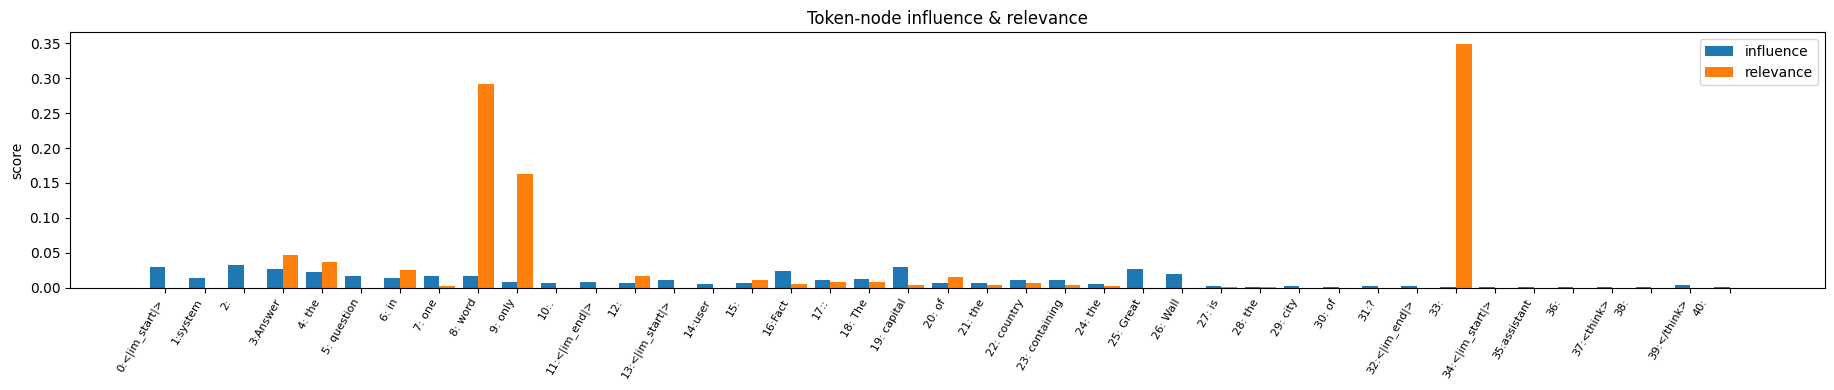

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Token nodes == embedding nodes. node_influence/node_relevance are indexed by node
# position over ALL nodes, so slice out the embedding indices.
emb_idx = _build_index_sets(prune_graph.nodes)["embedding"]

ni = prune_graph.node_influence.float().cpu()
nr = prune_graph.node_relevance.float().cpu()

tok_infl = ni[emb_idx].numpy()
tok_rel = nr[emb_idx].numpy()

# Label each embedding node by its token (ctx_idx → prompt_tokens), keeping ctx order.
labels = []
for i in emb_idx:
    n = prune_graph.nodes[i]
    tok = prompt_tokens[n.ctx_idx] if n.ctx_idx < len(prompt_tokens) else f"[{n.ctx_idx}]"
    labels.append(f"{n.ctx_idx}:{tok}")

order = np.argsort([prune_graph.nodes[i].ctx_idx for i in emb_idx])
labels = [labels[k] for k in order]
tok_infl = tok_infl[order]
tok_rel = tok_rel[order]

x = np.arange(len(labels))
w = 0.4
fig, ax = plt.subplots(figsize=(max(8, 0.45 * len(labels)), 4))
ax.bar(x - w / 2, tok_infl, w, label="influence")
ax.bar(x + w / 2, tok_rel, w, label="relevance")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("score")
ax.set_title("Token-node influence & relevance")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
from api import save_subgraph

model_id = graph.cfg.tokenizer_name   # must match the parent graph's Neuronpedia modelId

labelled = [
    [f"cluster_{i}", *cluster]
    for i, cluster in enumerate(clusters)
    if len(cluster) > 1
]

status, body = save_subgraph(
    modelId=model_id,
    slug="Bejing",                          # parent graph slug already on Neuronpedia
    displayName="Beijing — ILP supernodes",
    pinnedIds=prune_graph.node_ids,
    supernodes=labelled,
    pruningThreshold=0.8,
    densityThreshold=0.99,
)
print(status, body[:500])
